## Student Performance Indicator

#### Life cycle of Machine learning Project

- Understanding the Problem Statement
- Data Collection
- Data Checks to perform
- Exploratory data analysis
- Data Pre-Processing
- Model Training
- Choose best model

### 1) Problem statement
- This project understands how the student's performance (test scores) is affected by other variables such as Gender, Ethnicity, Parental level of education, Lunch and Test preparation course.


### 2) Data Collection
- Dataset Source - https://www.kaggle.com/datasets/spscientist/students-performance-in-exams?datasetId=74977
- The data consists of 8 column and 1000 rows.

#### Import Data and Required Packages


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

#### Importing CSV File

In [2]:
df = pd.read_csv("D:/AI-ML/mlproject/notebook/data/stud.csv")

In [3]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [7]:
print("Dataset shape [Rows x Columns]:", df.shape)

Dataset shape [Rows x Columns]: (1000, 8)


#### Dataset Information

- gender : sex of student (male/female)
- race_ethnicity : ethnicity of student (group A,B,C,D,E)
- parental_level_of_education : parent's education (bachelor's degree,some college,master's degree,associate's degree,high school)
- lunch : having lunch before test (standard & free/reduced)
- test_preparation_course : preparation for test (completed & none)
- math_score
- reading_score
- writing_score

### 3. Data Cleaning

In [8]:
# Checking for missing value
df.isna().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

- There is no missing value in the dataset.

In [10]:
# Check Duplicate
df.duplicated().sum()

np.int64(0)

- There is no duplicate value in our dataset.

In [11]:
# Check Data Types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race_ethnicity               1000 non-null   str  
 2   parental_level_of_education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test_preparation_course      1000 non-null   str  
 5   math_score                   1000 non-null   int64
 6   reading_score                1000 non-null   int64
 7   writing_score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


In [13]:
# Checking unique values of each column
df.nunique()

gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
math_score                     81
reading_score                  72
writing_score                  77
dtype: int64

In [14]:
# Check statistics of dataset
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


#### Insight
- From above description of numerical data, all means are very close to each other - between 66 and 68.05;
- All standard deviations are also close - between 14.6 and 15.19;
- While there is a minimum score  0 for math, for writing minimum is much higher = 10 and for reading myet higher = 17

In [26]:
# Check various category present in the different categorical column

print(f"Categories in gender column: {df['gender'].unique().tolist()}")
print(f"Categories in race_ethnicity :{df['race_ethnicity'].unique().tolist()}")
print(f"Categories in parental_level_of_education : {df['parental_level_of_education'].unique().tolist()}")
print(f"Categories in lunch : {df['lunch'].unique().tolist()}")
print(f"Categories in test_preparation_course : {df['test_preparation_course'].unique().tolist()}")

Categories in gender column: ['female', 'male']
Categories in race_ethnicity :['group B', 'group C', 'group A', 'group D', 'group E']
Categories in parental_level_of_education : ["bachelor's degree", 'some college', "master's degree", "associate's degree", 'high school', 'some high school']
Categories in lunch : ['standard', 'free/reduced']
Categories in test_preparation_course : ['none', 'completed']


In [32]:
# Define numerical & categorical columns

numeric_feature = df.select_dtypes(include=['number']).columns.tolist()
categorical_feature = df.select_dtypes(include=['object', 'string', 'category']).columns.tolist()

print("Numerical Features:", numeric_feature)
print("Categorical Features:", categorical_feature)

Numerical Features: ['math_score', 'reading_score', 'writing_score']
Categorical Features: ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']


#### Adding two more columns : "Total Score" & "Average Score"

In [33]:
df['total_score'] = df['math_score'] + df['reading_score'] + df['writing_score']
df['average'] = df['total_score'] / 3
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [37]:
math_full_marks = df[df['math_score'] == 100]['average'].count()
reading_full_marks = df[df['reading_score'] == 100]['average'].count()
writing_full_marks = df[df['writing_score'] == 100]['average'].count()

print(f"Student with full marks in maths : {math_full_marks}")
print(f"Student with full marks in reading : {reading_full_marks}")
print(f"Student with full marks in writing : {writing_full_marks}")

Student with full marks in maths : 7
Student with full marks in reading : 17
Student with full marks in writing : 14


In [38]:
math_less_20 = df[df['math_score'] <= 20]['average'].count()
reading_less_20 = df[df['reading_score'] <= 20]['average'].count()
writing_less_20 = df[df['writing_score'] <= 20]['average'].count()

print(f"Student with marks less than 20 in maths : {math_less_20}")
print(f"Student with marks less than 20 in reading : {reading_less_20}")
print(f"Student with marks less than 20 in writing : {writing_less_20}")

Student with marks less than 20 in maths : 4
Student with marks less than 20 in reading : 1
Student with marks less than 20 in writing : 3


#### Insight
- Student has performed worst in maths because there is low full marks and high less marks
- Student has performed best in reading because we have much higher number for full marks

### 4. Data Visualization

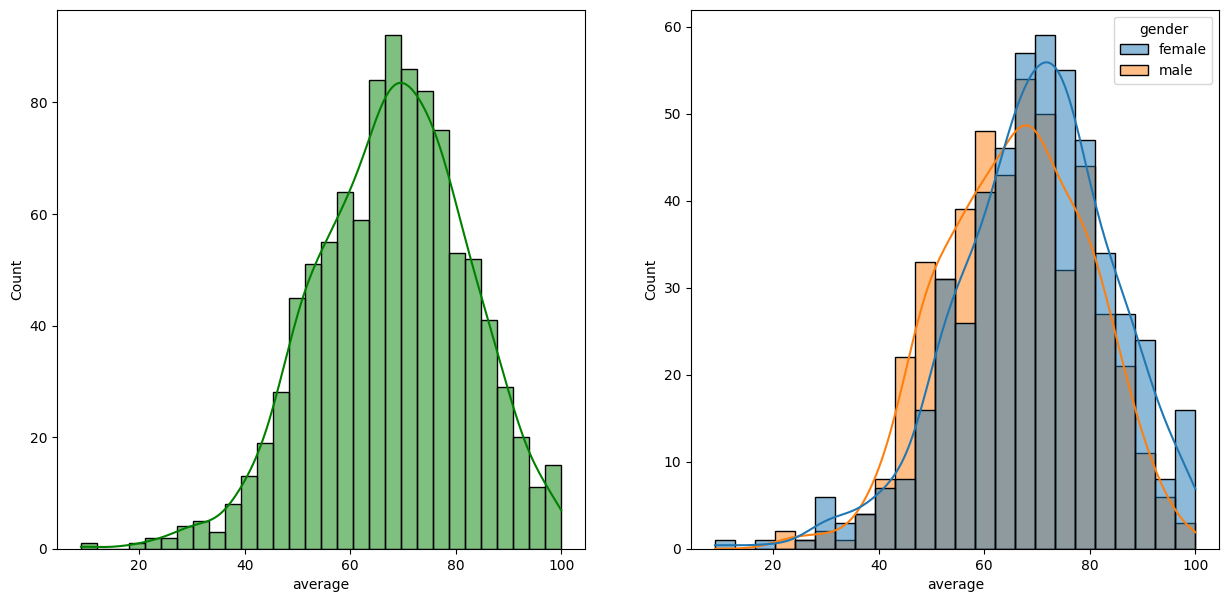

In [39]:
# Histogram and Kernal Distribution Function

fig, axs = plt.subplots(1, 2, figsize = (15,7))
plt.subplot(121)
sns.histplot(data = df, x = 'average', bins = 30, kde = True, color = 'g')
plt.subplot(122)
sns.histplot(data = df, x = 'average', kde = True, hue = 'gender')
plt.show()

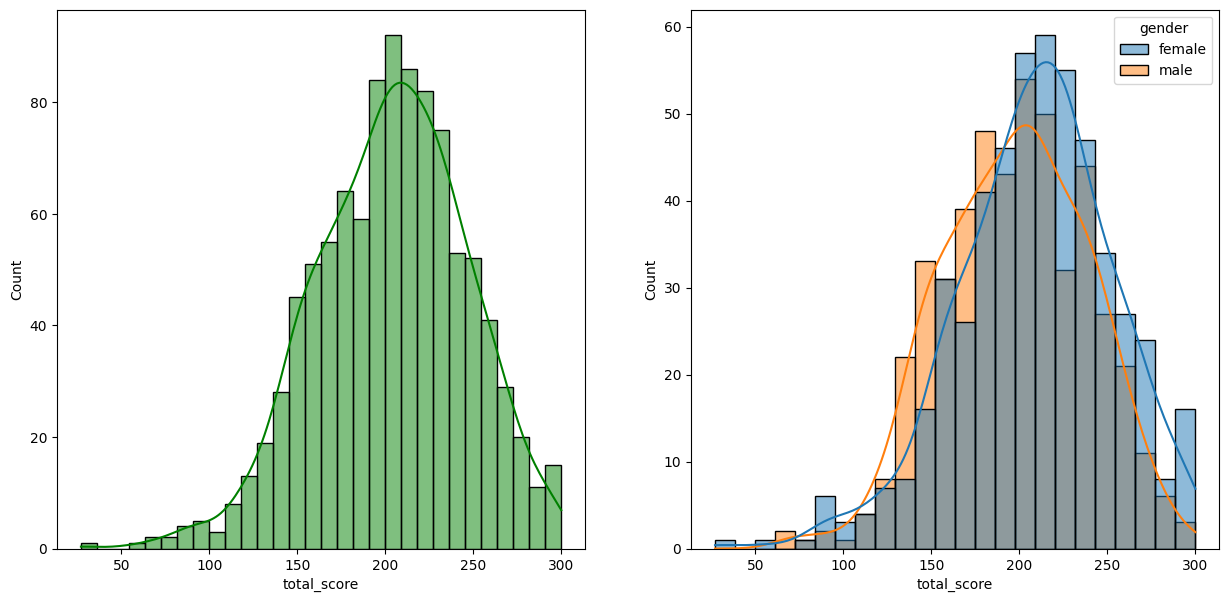

In [40]:
# Histogram and Kernal Distribution Function

fig, axs = plt.subplots(1, 2, figsize = (15,7))
plt.subplot(121)
sns.histplot(data = df, x = 'total_score', bins = 30, kde = True, color = 'g')
plt.subplot(122)
sns.histplot(data = df, x = 'total_score', kde = True, hue = 'gender')
plt.show()

#### Insight
- Female student are performing prettry good.

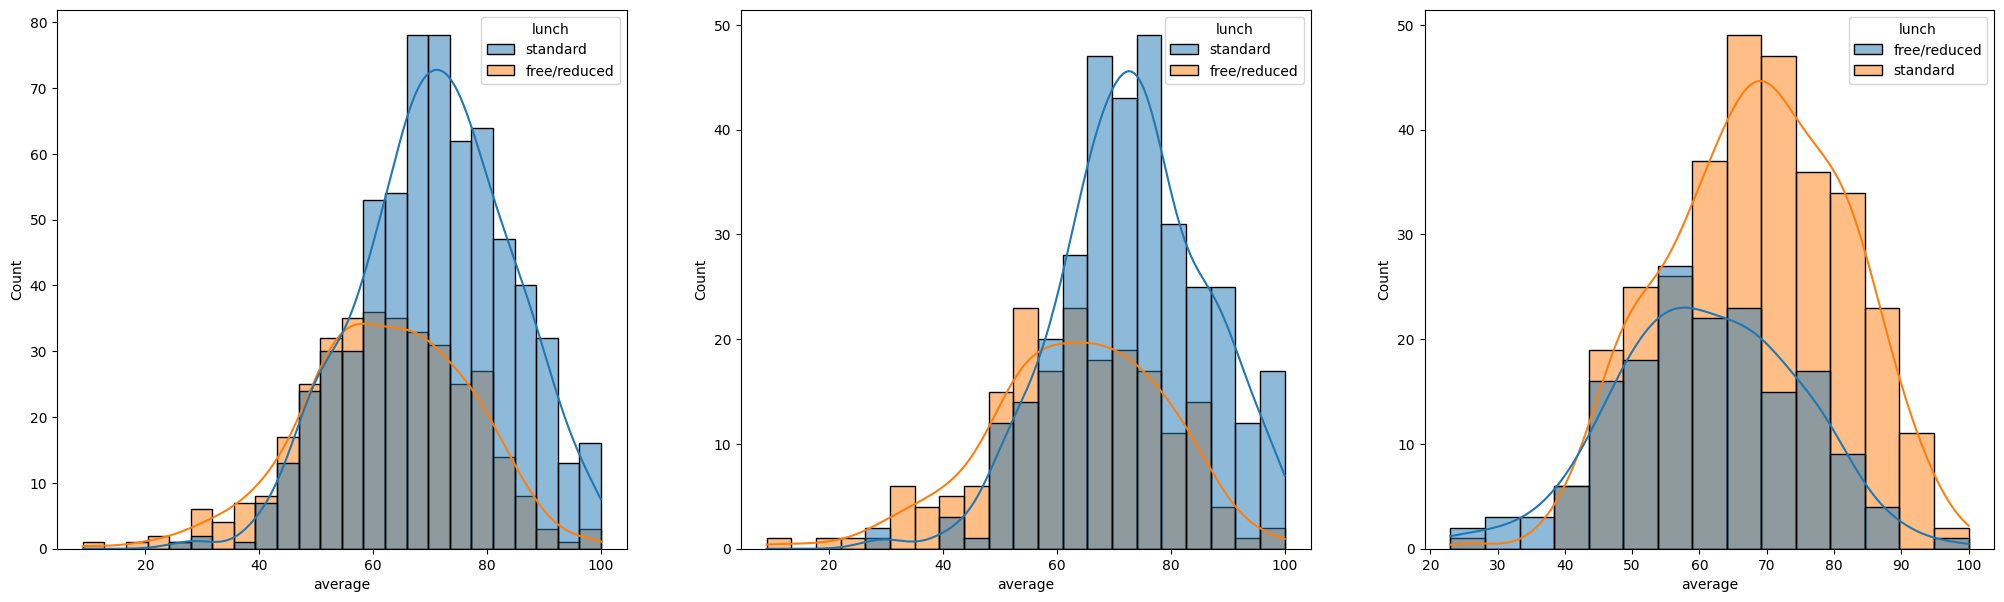

In [47]:
plt.subplots(1, 3, figsize = (25,7))
plt.subplot(131)
sns.histplot(data = df, x = 'average', kde = True, hue = 'lunch')
plt.subplot(132)
sns.histplot(data = df[df.gender == 'female'], x = 'average', kde = True, hue = 'lunch')
plt.subplot(133)
sns.histplot(data = df[df.gender == 'male'], x = 'average', kde = True, hue = 'lunch')
plt.show()

#### Insight 
- Standard lunch is helping to perform well in exam.
- It is helping both gender

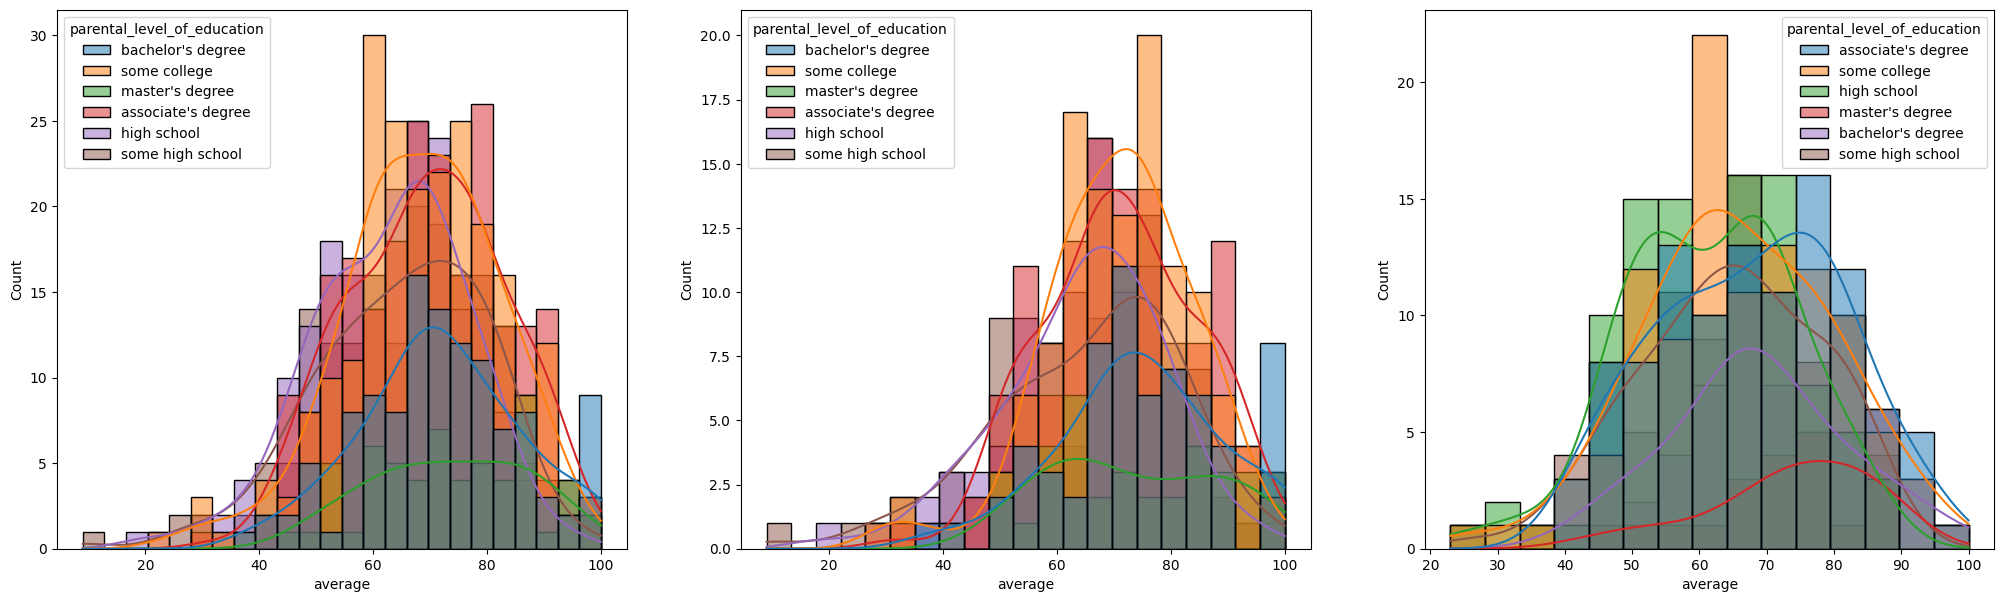

In [48]:
plt.subplots(1, 3, figsize = (25,7))
plt.subplot(131)
ax = sns.histplot(data = df, x = 'average', kde = True, hue = 'parental_level_of_education')
plt.subplot(132)
ax = sns.histplot(data = df[df.gender == 'female'], x = 'average', kde = True, hue = 'parental_level_of_education')
plt.subplot(133)
ax = sns.histplot(data = df[df.gender == 'male'], x = 'average', kde = True, hue = 'parental_level_of_education')


#####  Insights
- In general parent's education don't help student perform well in exam.
- 2nd plot we can see there is no effect of parent's education on female students.
- 3rd plot shows that parent's whose education is of associate's degree or master's degree their male child tend to perform well in exam


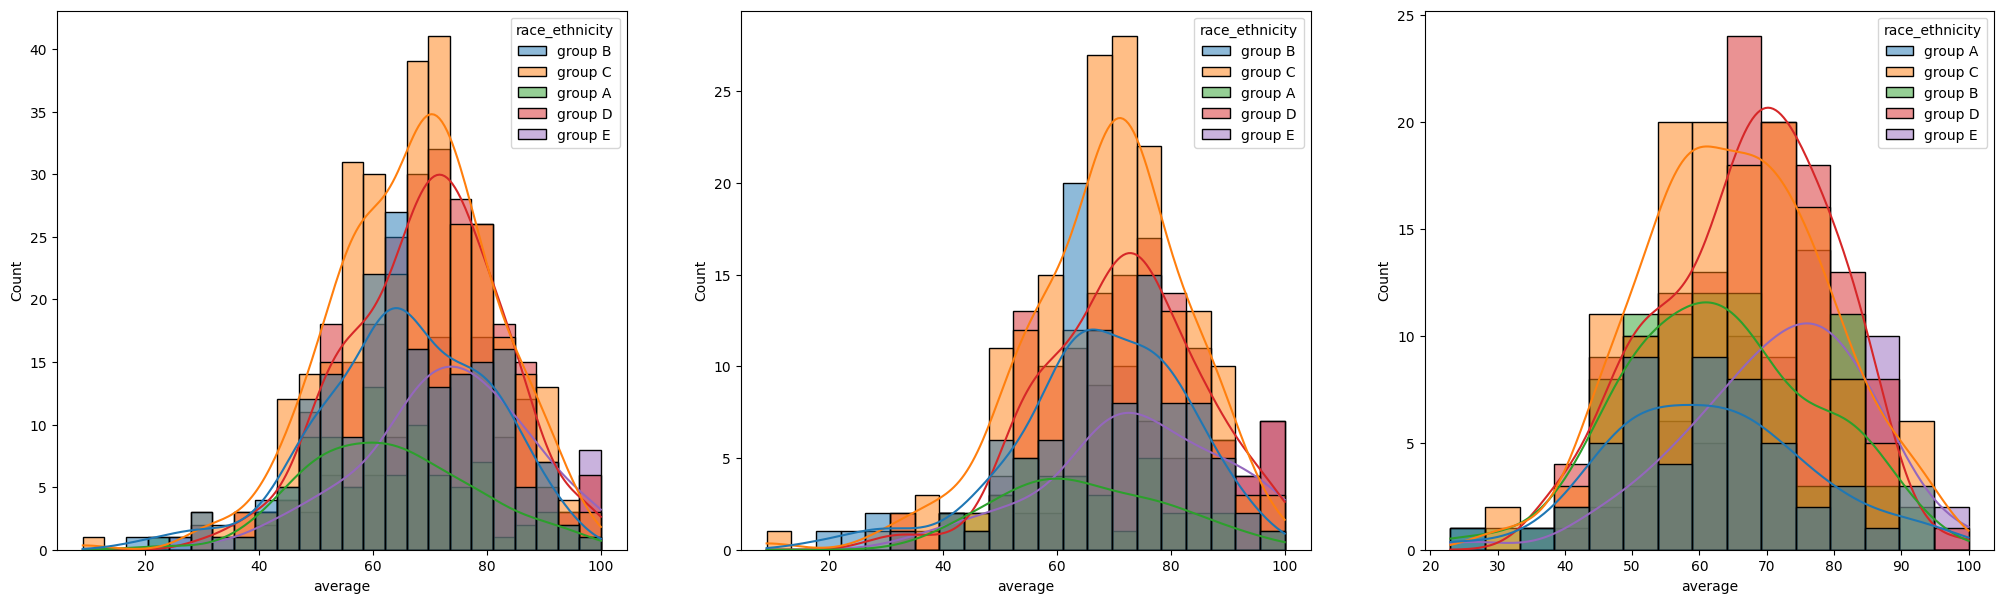

In [49]:
plt.subplots(1, 3, figsize = (25,7))
plt.subplot(131)
ax = sns.histplot(data = df, x = 'average', kde = True, hue = 'race_ethnicity')
plt.subplot(132)
ax = sns.histplot(data = df[df.gender == 'female'], x = 'average', kde = True, hue = 'race_ethnicity')
plt.subplot(133)
ax = sns.histplot(data = df[df.gender == 'male'], x = 'average', kde = True, hue = 'race_ethnicity')


#####  Insights
- Students of group A and group B tends to perform poorly in exam.
- Students of group A and group B tends to perform poorly in exam irrespective of whether they are male or female

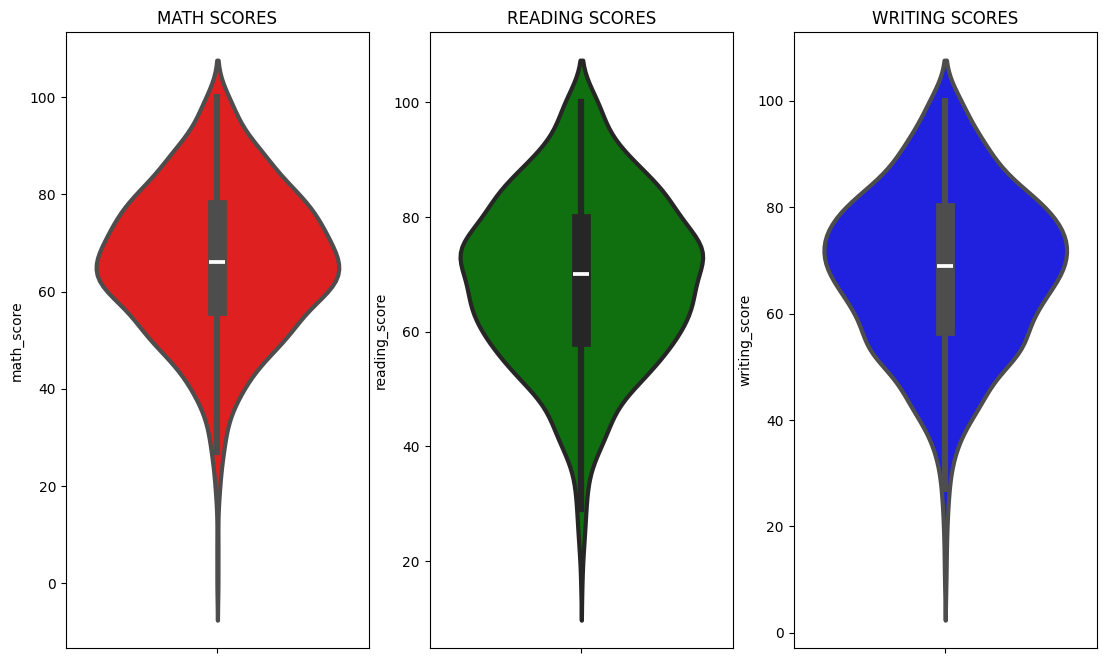

In [51]:
# Maximum score of student in all three subject


plt.figure(figsize=(18,8))
plt.subplot(1, 4, 1)
plt.title('MATH SCORES')
sns.violinplot(y='math_score',data=df,color='red',linewidth=3)
plt.subplot(1, 4, 2)
plt.title('READING SCORES')
sns.violinplot(y='reading_score',data=df,color='green',linewidth=3)
plt.subplot(1, 4, 3)
plt.title('WRITING SCORES')
sns.violinplot(y='writing_score',data=df,color='blue',linewidth=3)
plt.show()

#### Insights
- From the above three plots its clearly visible that most of the students score in between 60-80 in Maths whereas in reading and writing most of them score from 50-80

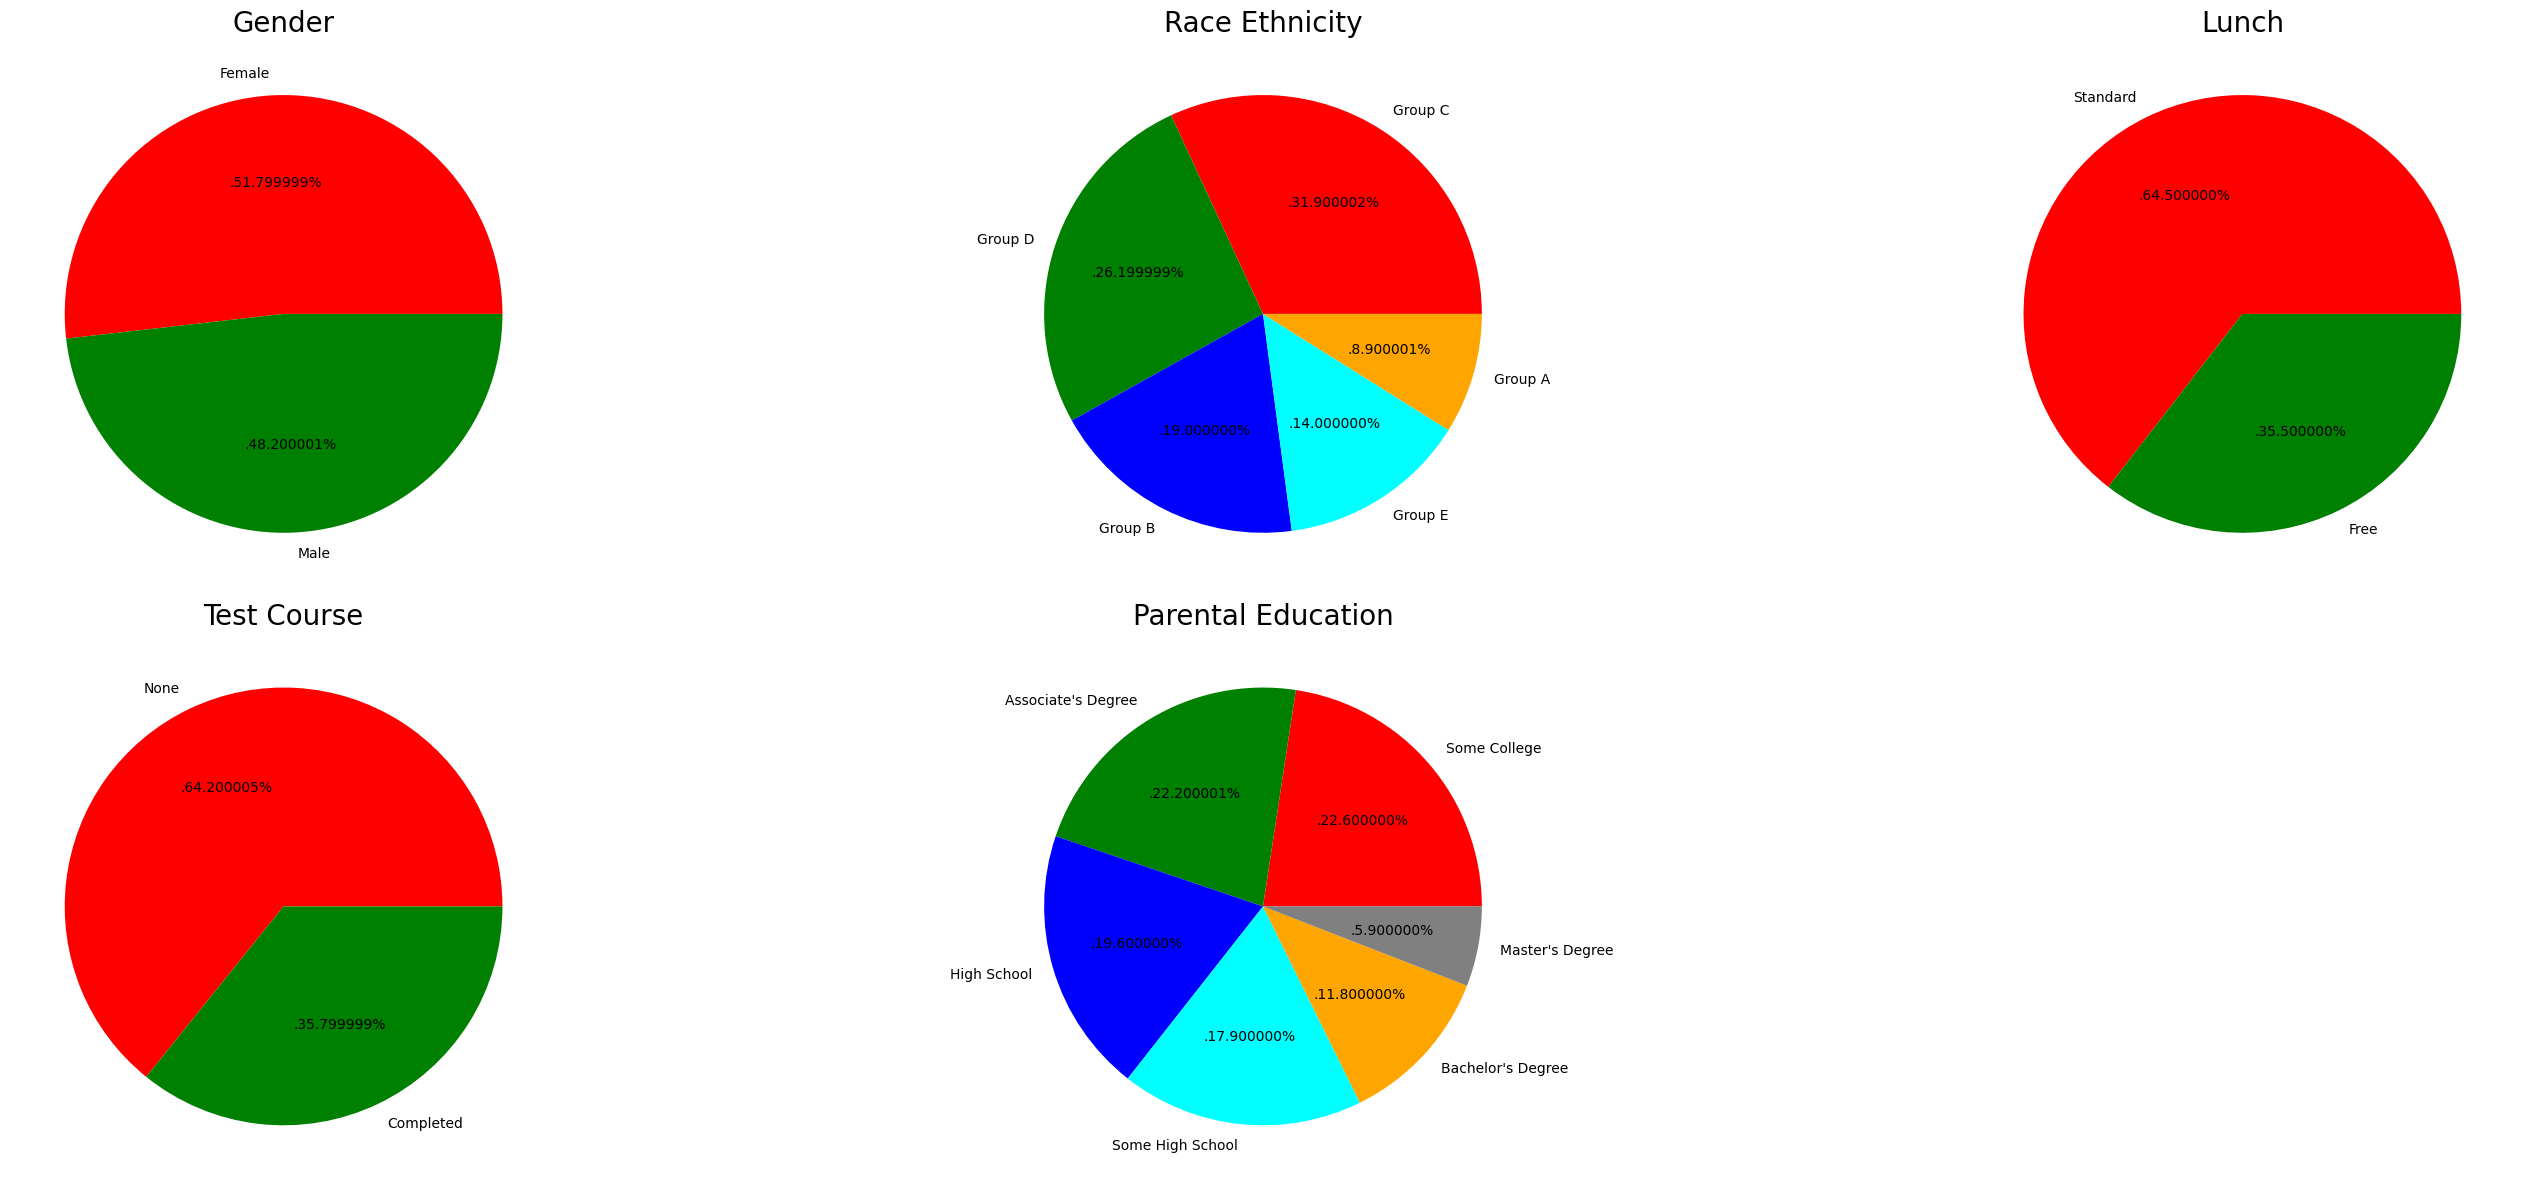

In [55]:
# Multivariate analysis using pieplot

plt.rcParams['figure.figsize'] = (30, 12)

plt.subplot(2, 3, 1)
size = df['gender'].value_counts()
labels = 'Female', 'Male'
color = ['red','green']
plt.pie(size, colors = color, labels = labels,autopct = '.%2f%%')
plt.title('Gender', fontsize = 20)
plt.axis('off')



plt.subplot(2, 3, 2)
size = df['race_ethnicity'].value_counts()
labels = 'Group C', 'Group D','Group B','Group E','Group A'
color = ['red', 'green', 'blue', 'cyan','orange']
plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('Race Ethnicity', fontsize = 20)
plt.axis('off')



plt.subplot(2, 3, 3)
size = df['lunch'].value_counts()
labels = 'Standard', 'Free'
color = ['red','green']
plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('Lunch', fontsize = 20)
plt.axis('off')


plt.subplot(2, 3, 4)
size = df['test_preparation_course'].value_counts()
labels = 'None', 'Completed'
color = ['red','green']
plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('Test Course', fontsize = 20)
plt.axis('off')


plt.subplot(2, 3, 5)
size = df['parental_level_of_education'].value_counts()
labels = 'Some College', "Associate's Degree",'High School','Some High School',"Bachelor's Degree","Master's Degree"
color = ['red', 'green', 'blue', 'cyan','orange','grey']
plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('Parental Education', fontsize = 20)
plt.axis('off')


plt.tight_layout()
plt.grid()

plt.show()

#####  Insights
- Number of Male and Female students is almost equal
- Number students are greatest in Group C
- Number of students who have standard lunch are greater
- Number of students who have not enrolled in any test preparation course is greater
- Number of students whose parental education is "Some College" is greater followed closely by "Associate's Degree"

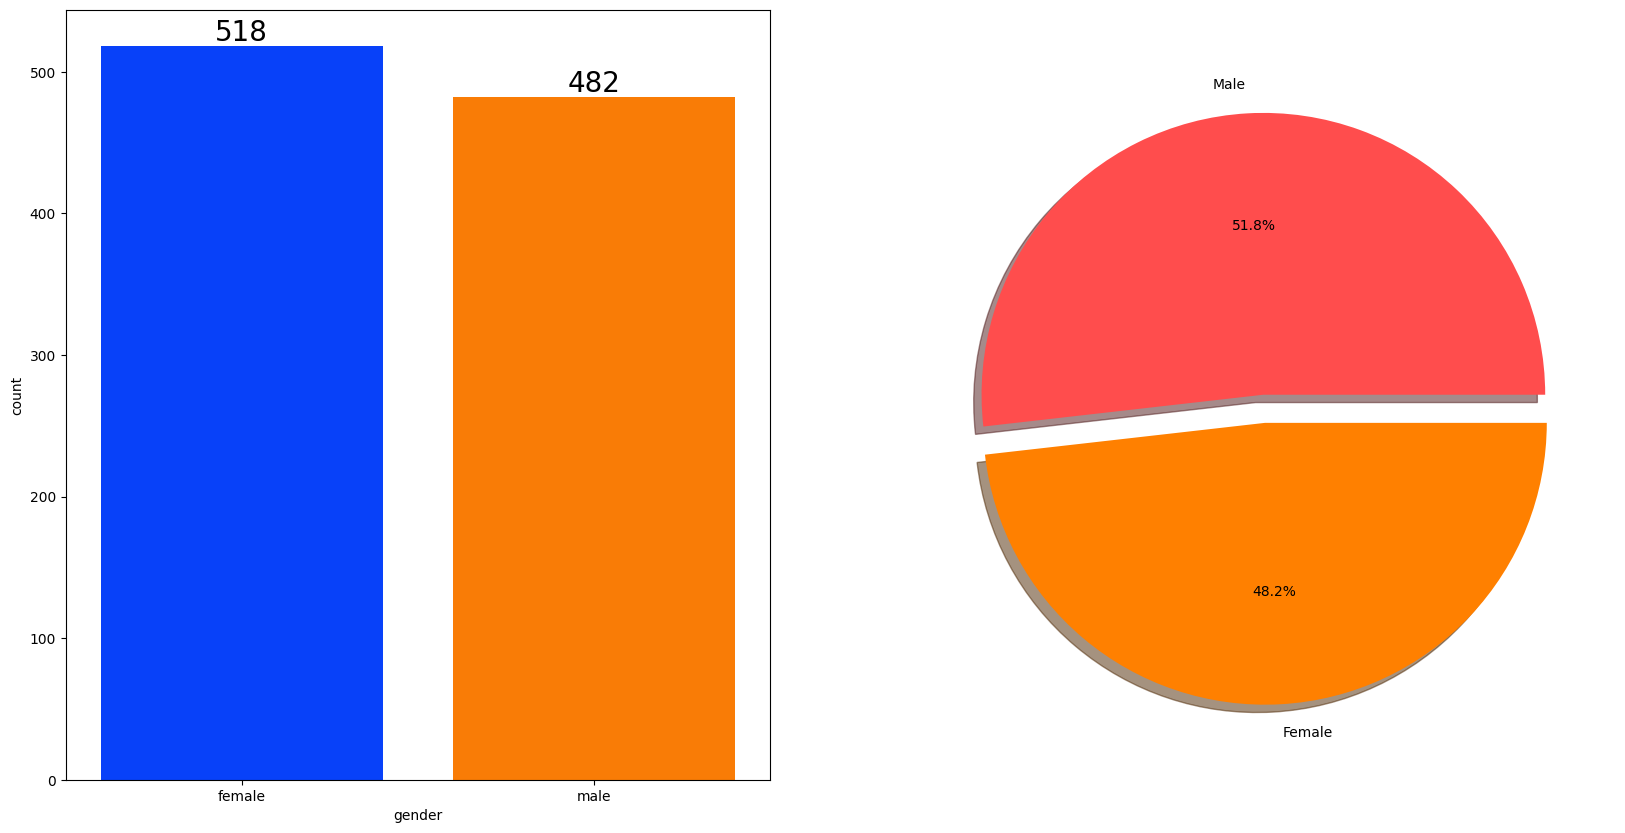

In [56]:
# Univariate Analysis [How is distribution of gendder?]

f, ax = plt.subplots(1, 2, figsize = (20,10))
sns.countplot(x = df['gender'], data = df, palette = 'bright', ax = ax[0], saturation = 0.95)
for container in ax[0].containers :
    ax[0].bar_label(container, color = 'black', size = 20)
plt.pie(x = df['gender'].value_counts(), labels = ['Male', 'Female'], explode = [0, 0.1], autopct = '%1.1f%%', shadow = True, colors =['#ff4d4d','#ff8000'])
plt.show()

#### Insights 
- Gender has balanced data with female students are 518 (48%) and male students are 482 (52%) 

In [58]:
# Bivariate Analysis [Is gender has any impact on student performance ?]

gender_group = df.groupby('gender').mean(numeric_only = True)
gender_group

,math_score,reading_score,writing_score,total_score,average
gender,,,,,
female,63.633205,72.608108,72.467181,208.708494,69.569498
male,68.728216,65.473029,63.311203,197.512448,65.837483


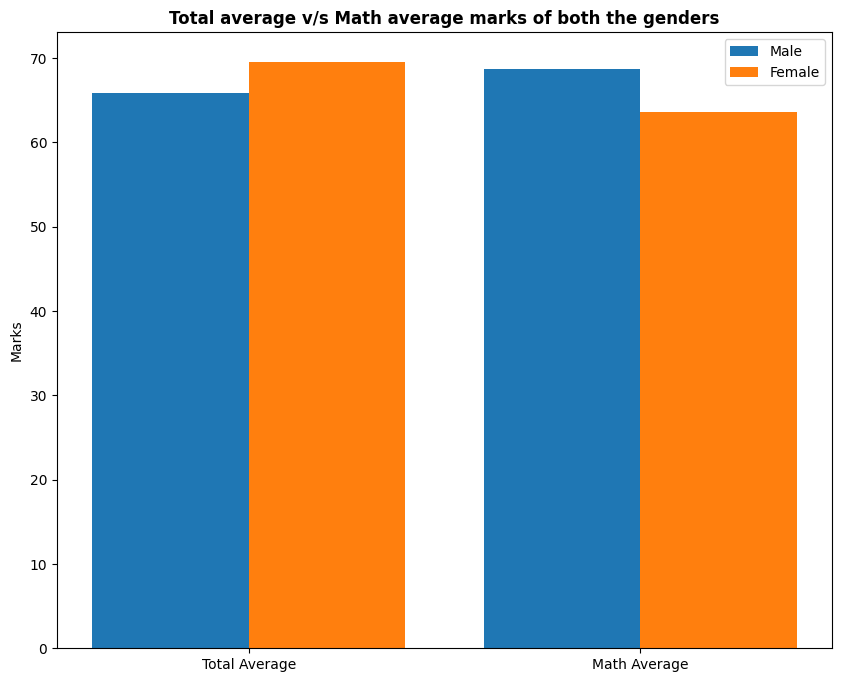

In [62]:
plt.figure(figsize = (10,8))

X = 'Total Average', 'Math Average'

female_scores = [
    gender_group.loc['female', 'average'],
    gender_group.loc['female', 'math_score']
]

male_scores = [
    gender_group.loc['male', 'average'],
    gender_group.loc['male', 'math_score']
]

X_axis = np.arange(len(X))

plt.bar(X_axis - 0.2, male_scores, 0.4, label = 'Male')
plt.bar(X_axis + 0.2, female_scores, 0.4, label = 'Female')

plt.xticks(X_axis, X)
plt.ylabel("Marks")
plt.title("Total average v/s Math average marks of both the genders", fontweight='bold')
plt.legend()
plt.show()

#### Insights 
- On an average females have a better overall score than men. Whereas males have scored higher in Maths.

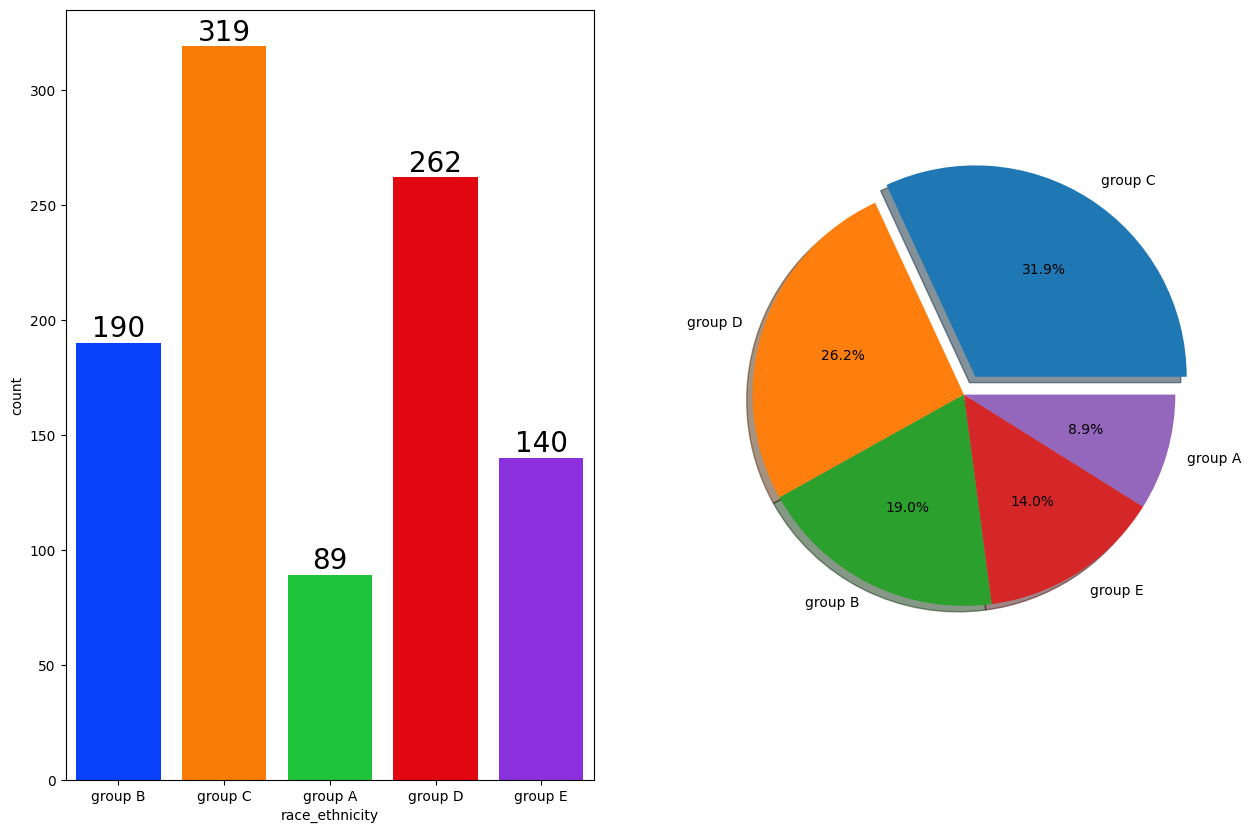

In [64]:
# Univariate Analysis [How is group wise distribution]

f,ax=plt.subplots(1, 2, figsize = (15,10))
sns.countplot(x = df['race_ethnicity'], data = df, palette = 'bright', ax = ax[0], saturation = 0.95)
for container in ax[0].containers:
    ax[0].bar_label(container, color = 'black', size = 20)
    
plt.pie(x = df['race_ethnicity'].value_counts(), labels = df['race_ethnicity'].value_counts().index,explode=[0.1, 0, 0, 0, 0], autopct='%1.1f%%', shadow = True)
plt.show()   

#### Insights 
- Most of the student belonging from group C /group D. Lowest number of students belong to groupA.

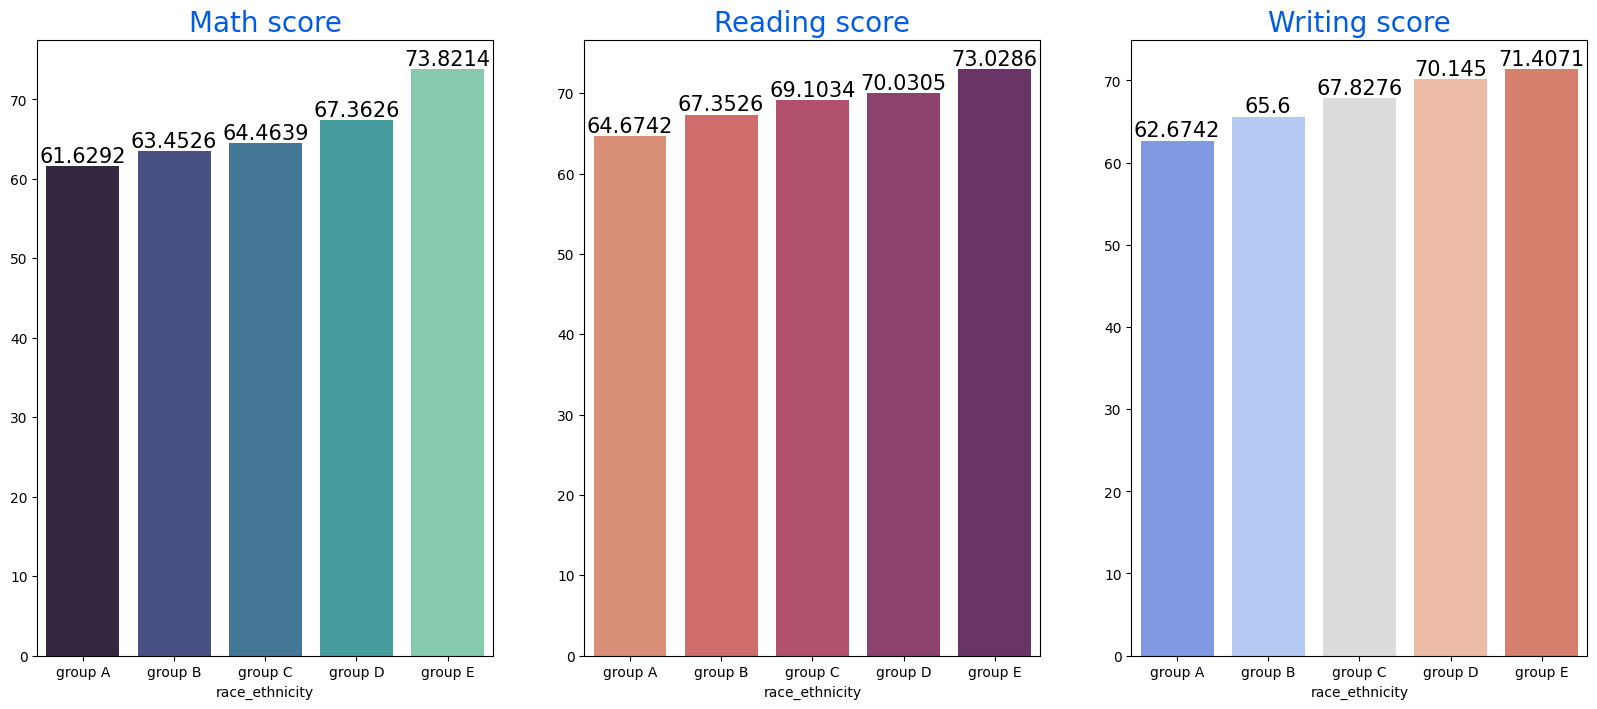

In [66]:
# Bivariate Analysis [Is Race Ehnicity has any impact on student's performance ?]

Group_data2 = df.groupby('race_ethnicity')
f, ax = plt.subplots(1, 3, figsize = (20,8))
sns.barplot(x = Group_data2['math_score'].mean().index, y = Group_data2['math_score'].mean().values, palette = 'mako', ax = ax[0])
ax[0].set_title('Math score', color = '#005ce6', size = 20)

for container in ax[0].containers:
    ax[0].bar_label(container, color = 'black', size = 15)

sns.barplot(x = Group_data2['reading_score'].mean().index, y = Group_data2['reading_score'].mean().values, palette = 'flare', ax = ax[1])
ax[1].set_title('Reading score', color ='#005ce6', size = 20)

for container in ax[1].containers:
    ax[1].bar_label(container, color = 'black', size = 15)

sns.barplot(x = Group_data2['writing_score'].mean().index, y = Group_data2['writing_score'].mean().values, palette = 'coolwarm', ax = ax[2])
ax[2].set_title('Writing score', color ='#005ce6', size = 20)

for container in ax[2].containers:
    ax[2].bar_label(container, color = 'black', size = 15)

#### Insights 
- Group E students have scored the highest marks. 
- Group A students have scored the lowest marks. 
- Students from a lower Socioeconomic status have a lower avg in all course subjects

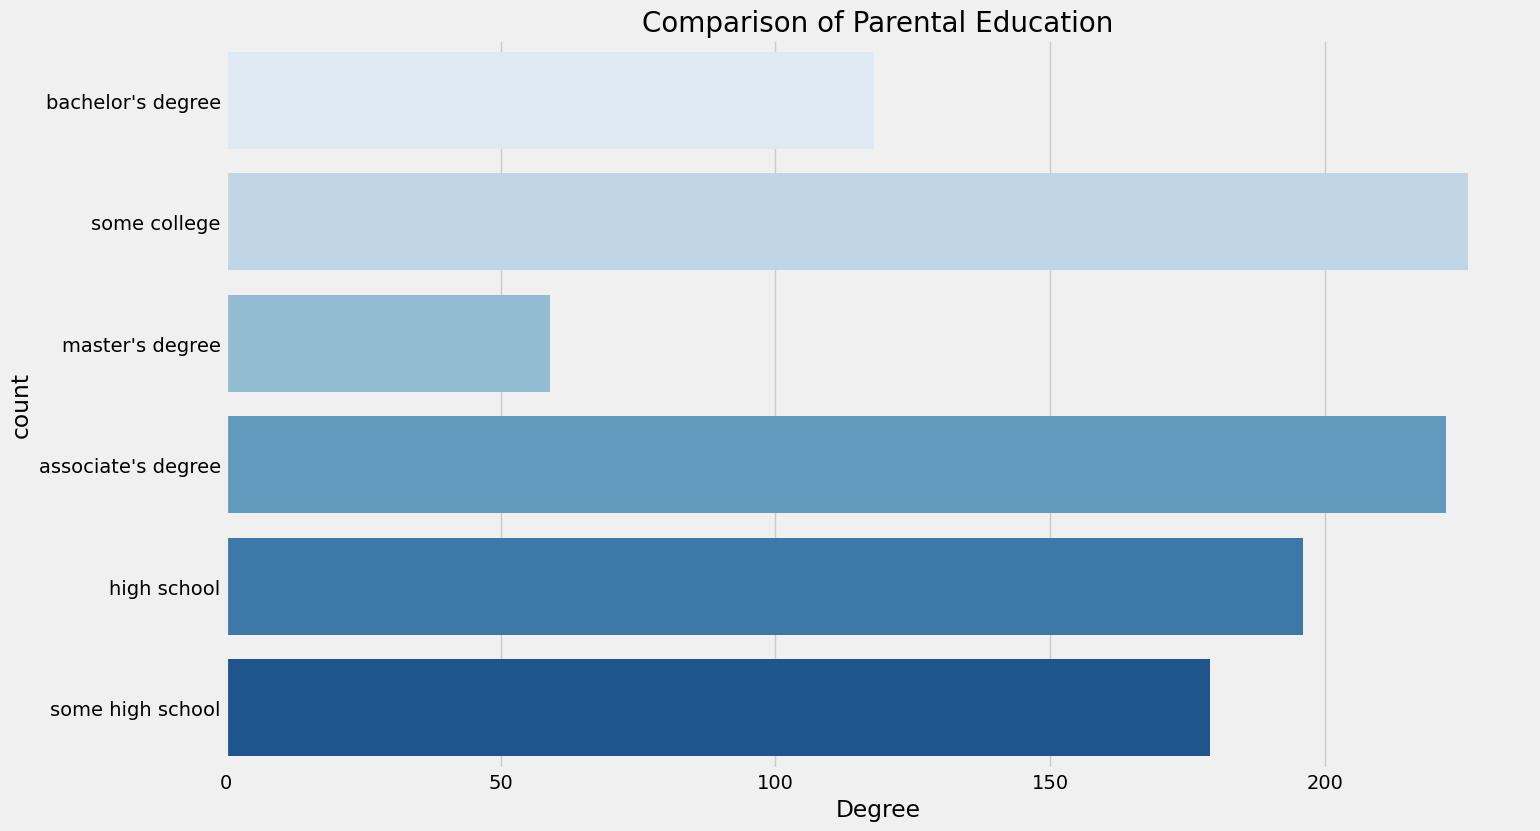

In [68]:
# UNIVARIATE ANALYSIS ( What is educational background of student's parent ? )

plt.rcParams['figure.figsize'] = (15, 9)
plt.style.use('fivethirtyeight')
sns.countplot(df['parental_level_of_education'], palette = 'Blues')
plt.title('Comparison of Parental Education', fontweight = 30, fontsize = 20)
plt.xlabel('Degree')
plt.ylabel('count')
plt.show()

#### Insights 
- Largest number of parents are from some college.

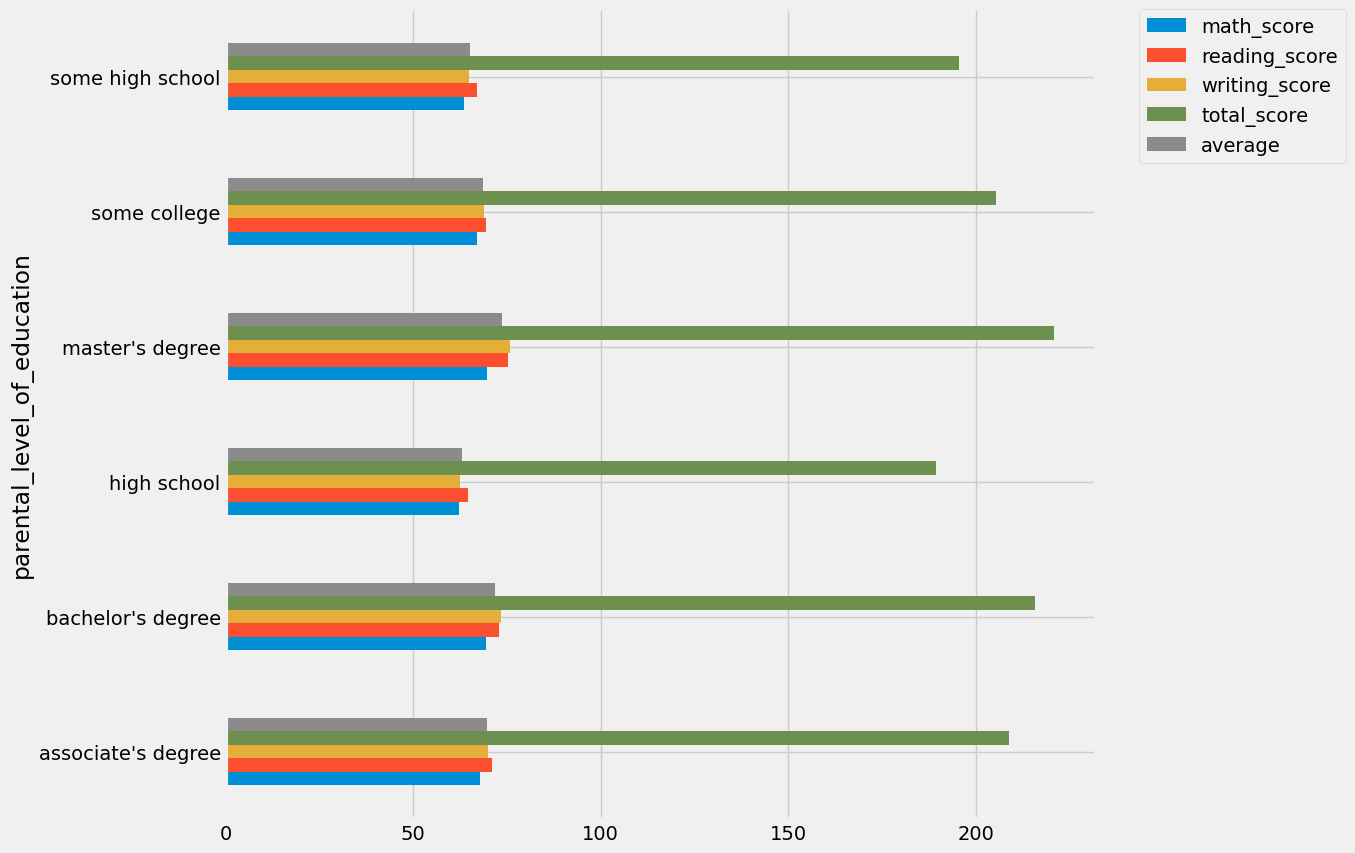

In [72]:
# BIVARIATE ANALYSIS ( Is parental education has any impact on student's performance ? )

df.groupby('parental_level_of_education').mean(numeric_only=True).plot(
    kind='barh',
    figsize=(10, 10)
)
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()

#### Insights 
- The score of student whose parents possess master and bachelor level education are higher than others.

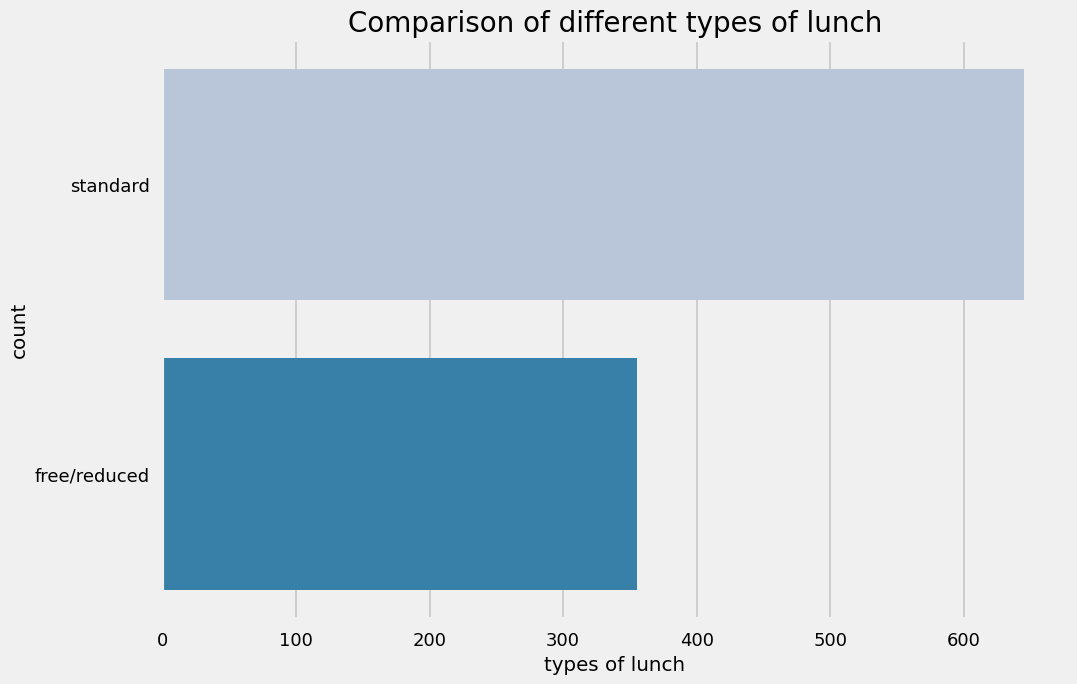

In [76]:
# UNIVARIATE ANALYSIS ( Which type of lunch is most common amoung students ? )

plt.rcParams['figure.figsize'] = (15, 9)
plt.style.use('seaborn-v0_8-talk')
sns.countplot(df['lunch'], palette = 'PuBu')
plt.title('Comparison of different types of lunch', fontweight = 30, fontsize = 20)
plt.xlabel('types of lunch')
plt.ylabel('count')
plt.show()

#### Insights 
- Students being served Standard lunch was more than free lunch

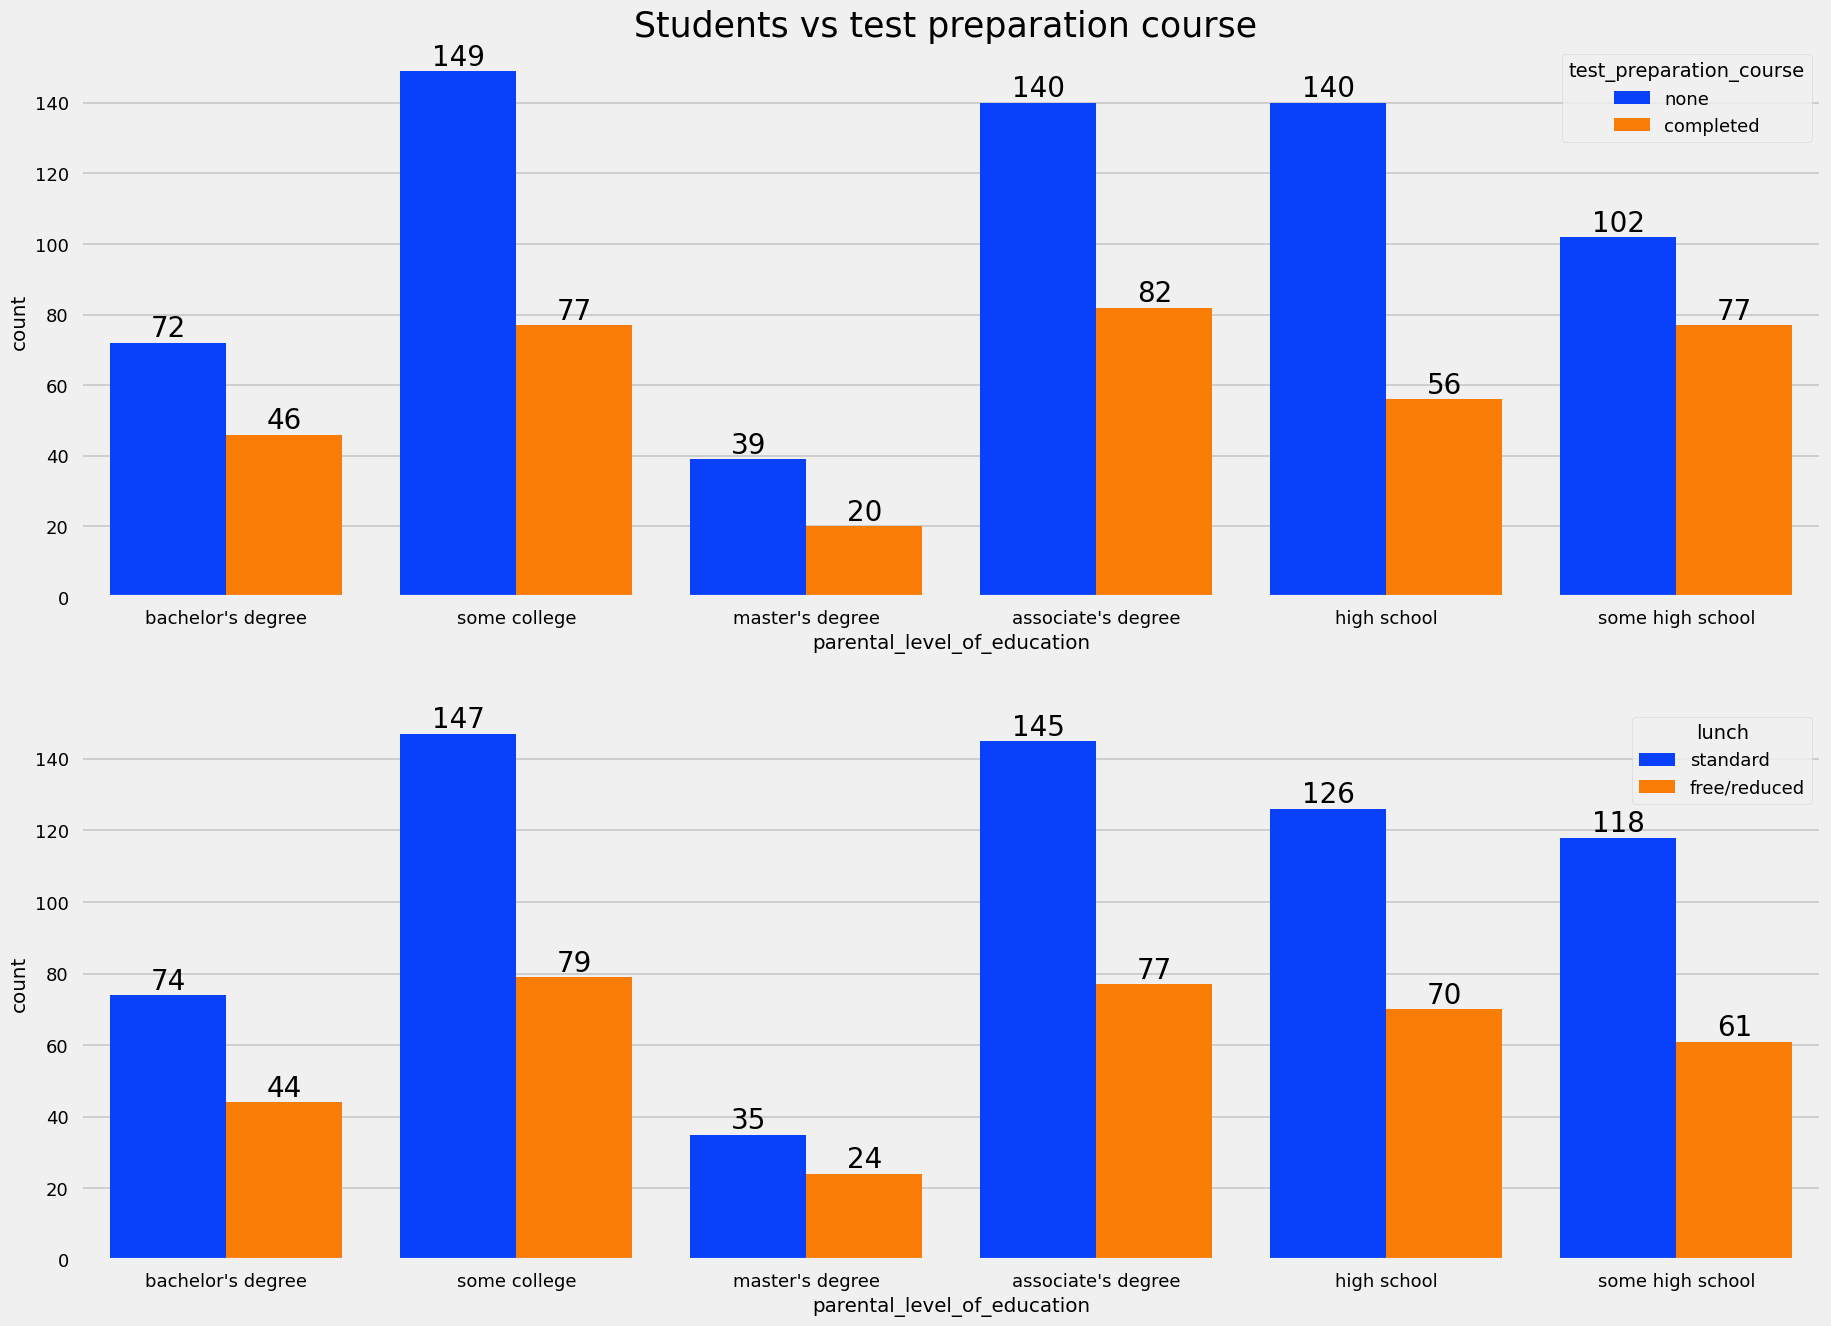

In [80]:
# BIVARIATE ANALYSIS (  Is lunch type intake has any impact on student's performance ? )

f, ax = plt.subplots(2, 1, figsize = (20,15))
sns.countplot(x = df['parental_level_of_education'], data = df, palette = 'bright', hue = 'test_preparation_course', saturation = 0.95, ax = ax[0])
ax[0].set_title('Students vs test preparation course ', color = 'black', size = 25)
for container in ax[0].containers:
    ax[0].bar_label(container, color = 'black', size = 20)
    
sns.countplot(x = df['parental_level_of_education'], data = df, palette = 'bright', hue = 'lunch', saturation = 0.95, ax = ax[1])
for container in ax[1].containers:
    ax[1].bar_label(container, color = 'black', size = 20)   

#### Insights 
- Students who get Standard Lunch tend to perform better than students who got free/reduced lunch

<Axes: xlabel='lunch', ylabel='writing_score'>

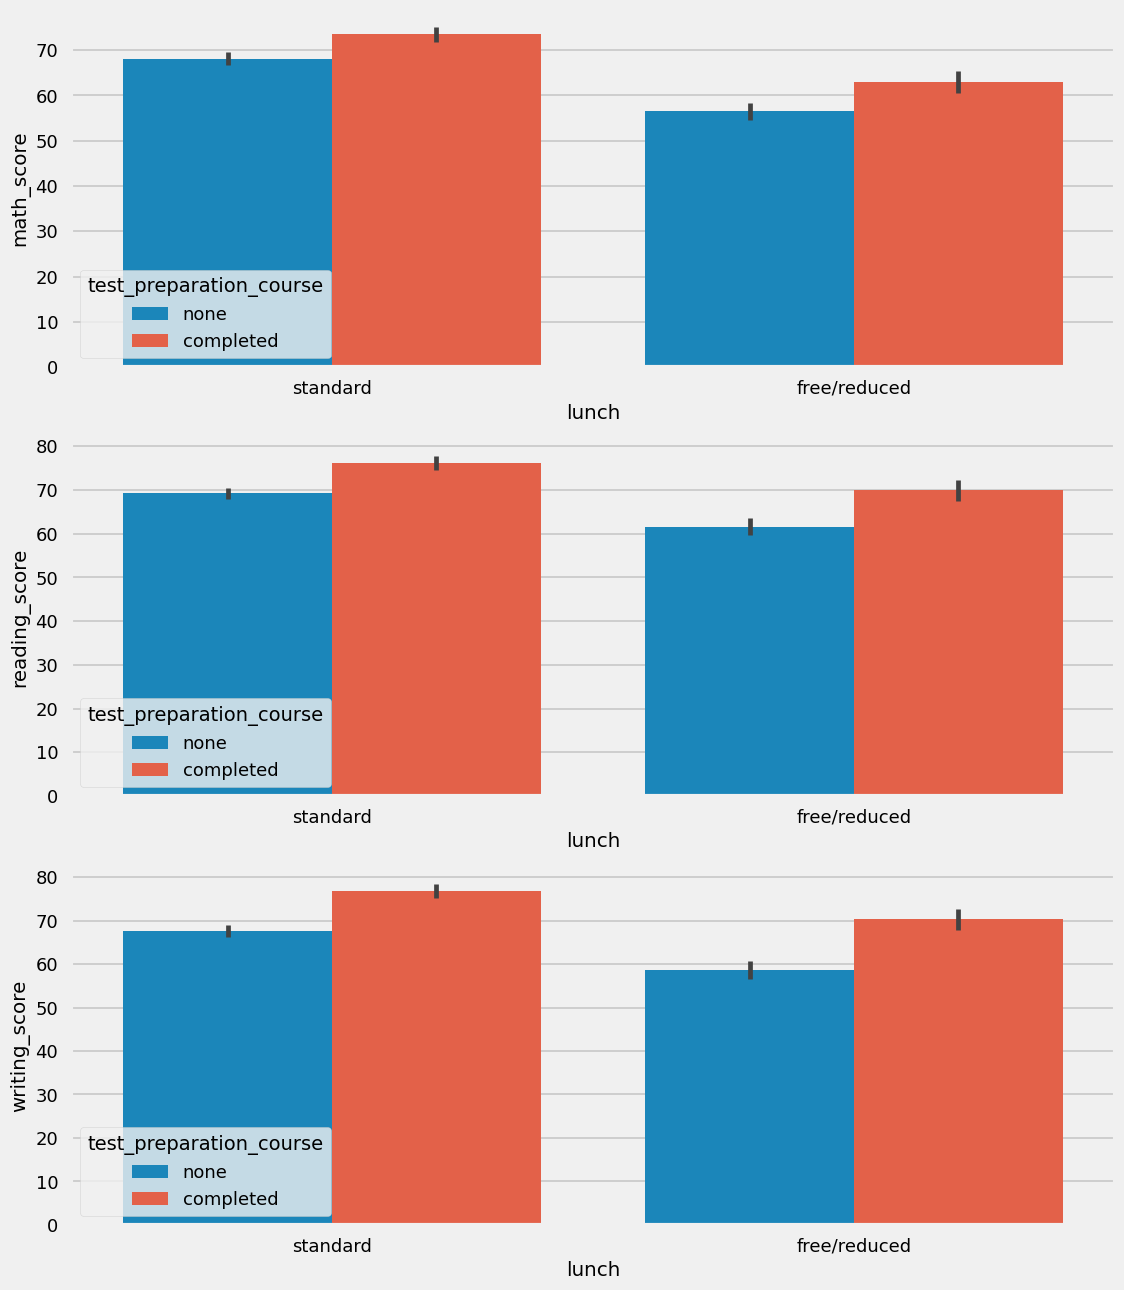

In [83]:
# BIVARIATE ANALYSIS ( Is Test prepration course has any impact on student's performance ? )

plt.figure(figsize=(12,15))
plt.subplot(3,1,1)
sns.barplot (x=df['lunch'], y=df['math_score'], hue=df['test_preparation_course'])
plt.subplot(3,1,2)
sns.barplot (x=df['lunch'], y=df['reading_score'], hue=df['test_preparation_course'])
plt.subplot(3,1,3)
sns.barplot (x=df['lunch'], y=df['writing_score'], hue=df['test_preparation_course'])

#### Insights  
- Students who have completed the Test Prepration Course have scores higher in all three categories than those who haven't taken the course

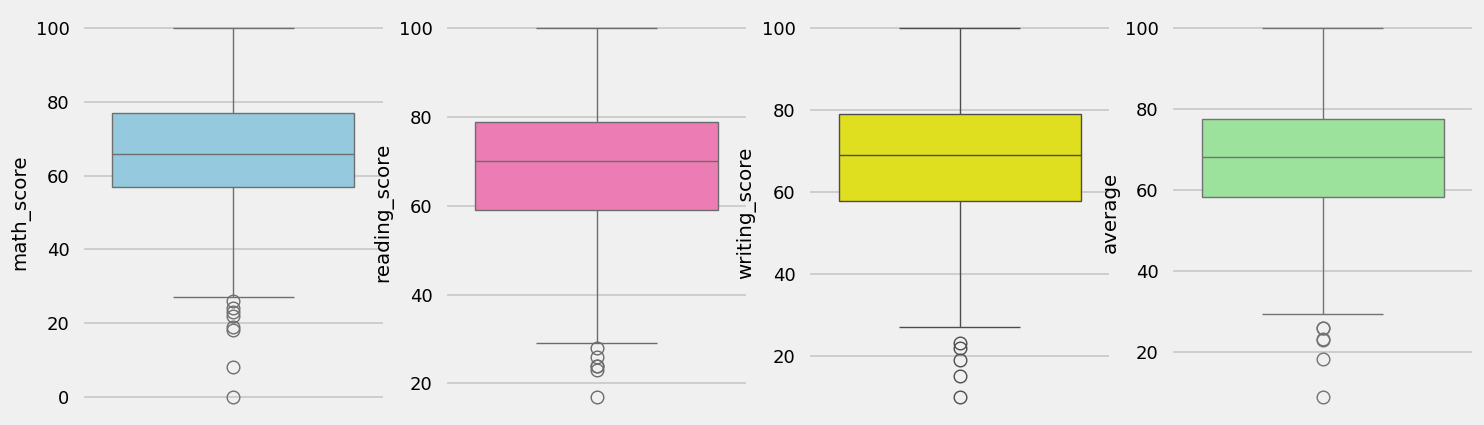

In [85]:
# Checking outliers

plt.subplots(1,4,figsize=(16,5))
plt.subplot(141)
sns.boxplot(df['math_score'],color='skyblue')
plt.subplot(142)
sns.boxplot(df['reading_score'],color='hotpink')
plt.subplot(143)
sns.boxplot(df['writing_score'],color='yellow')
plt.subplot(144)
sns.boxplot(df['average'],color='lightgreen')
plt.show()

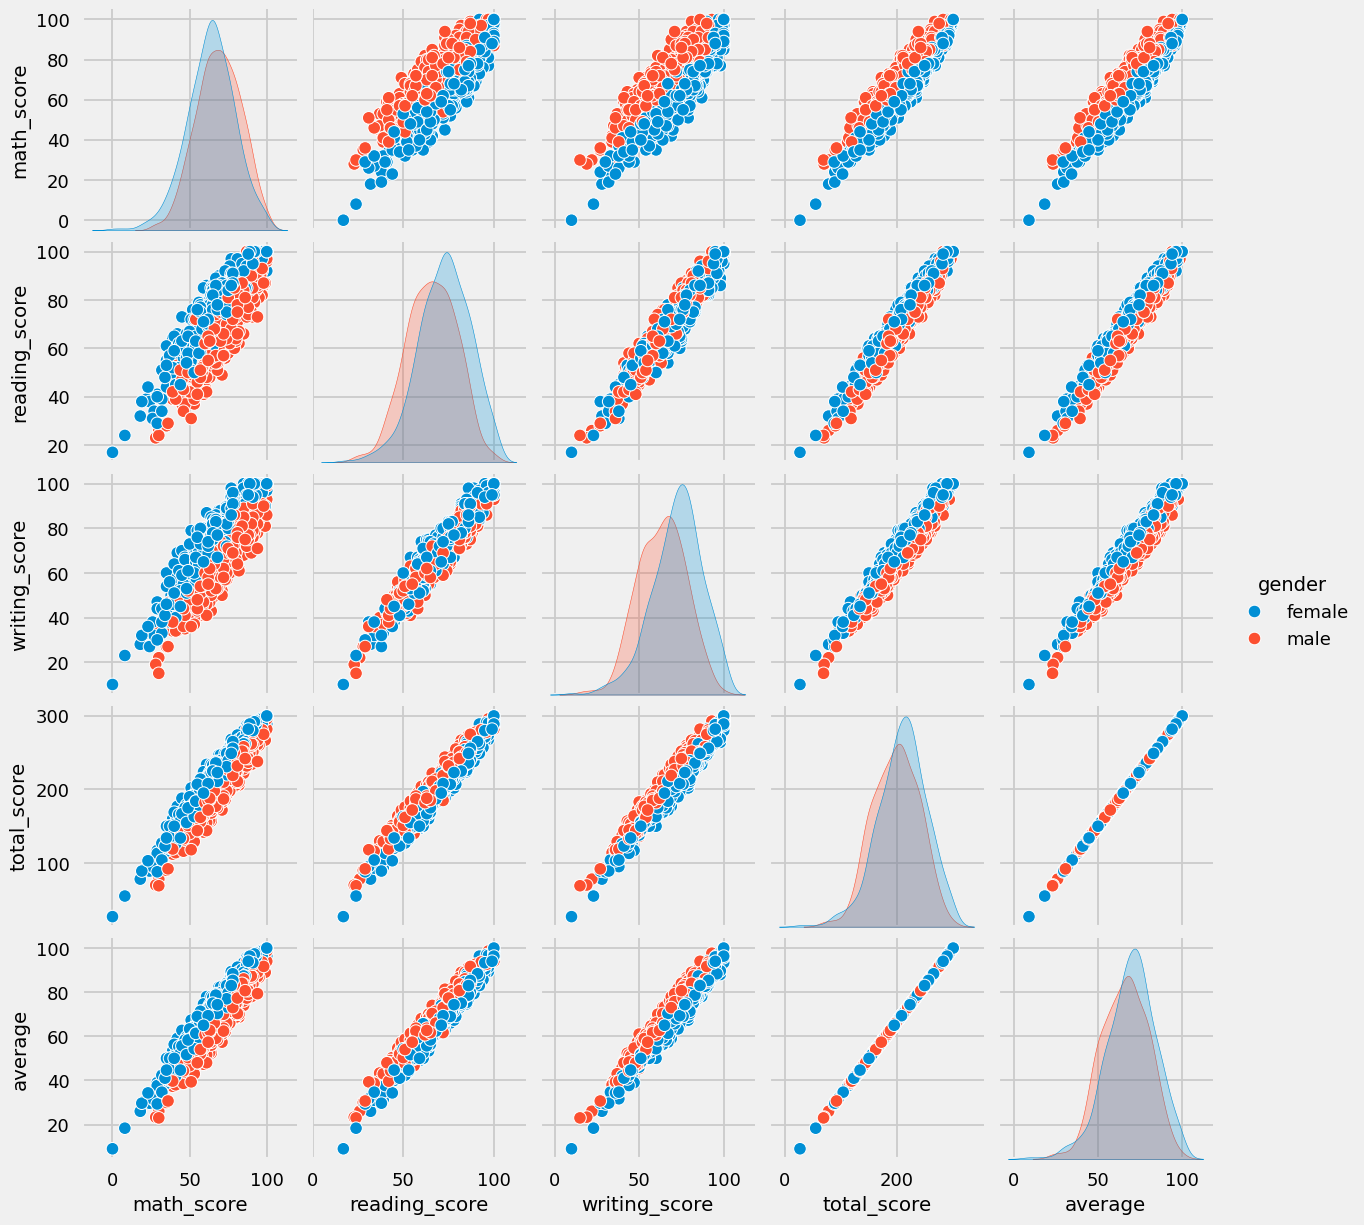

In [86]:
# Multivariate analysis using pairplot

sns.pairplot(df,hue = 'gender')
plt.show()

#### Insights
- From the above plot it is clear that all the scores increase linearly with each other.

### 5. Conclusions
- Student's Performance is related with lunch, race, parental level education
- Females lead in pass percentage and also are top-scorers
- Student's Performance is not much related with test preparation course
- Finishing preparation course is benefitial.